# Measuring Laser Extrinsic Drift Across a Flat Port

FishSense measures a fish by combining a **range** from its laser with a
**transverse size** from the camera. `pool_validation.ipynb` dealt with the
camera. This notebook deals with the laser.

The optics permit a dry calibration:

> A beam at **normal incidence** on a flat interface passes undeviated for any
> refractive index. So if the laser fires parallel to the port normal, the beam
> measured in air *is* the beam in water.

The optics, however, are not the binding constraint. **FishSense laser extrinsics
are known not to be stable** — which is why the production pipeline calibrates the
laser *per dive* from the dive's own dots rather than trusting a stored
calibration (see `laser_label_analysis.ipynb` in `imwut_2026_fishsense_lite`,
which fits a line per `dive_id`, and the robust-fitting studies alongside it).

So this notebook is not a test of whether dry laser calibration is viable. It is a
**measurement of how far the extrinsics move**, using two independent fits of the
same beam 48 minutes and one hand-carry apart — and a check that whatever
disagreement appears is drift rather than refraction.

The division of labour that follows is: the **camera** is calibrated once in air,
which is what Pinax buys; the **laser** is self-calibrated per dive, which is what
the drift measured here requires.

The 2024-05-01 dataset can test this, because the laser was on in both media with
the checkerboard in frame:

- **21 garage frames** (066-086): dot on the board, in air
- **11 pool frames** (239-261): dot on the board, underwater

Each gives one 3D point on the beam: `solvePnP` fixes the board plane, and the
camera ray through the dot is intersected with it. Two independent line fits, one
per medium, and the question is how closely they agree.

Everything here is in **raw sensor coordinates**. The dots come from
`LinearRawImage.bayer_excess` — per-super-cell green excess computed before
demosaic — which matters because the in-air frames were shot at f/2 against
water's f/8 and their green channel is ~30% clipped at the dot. A JPEG centroid
on a clipped blob is biased; on these frames it was wrong by up to 18 px. The
excess channel does not clip and recovers all 32 dots, against 27 from the JPEGs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from fishsense_wuwnet.dataset import (
    PATTERN,
    board_object_points,
    cache_by_session,
    fit_line,
    load_corner_cache,
)
from fishsense_wuwnet.refraction import SWEET_WATER, FlatPort, exit_ray

In [2]:
IMAGE_WIDTH, IMAGE_HEIGHT = 4014, 3016   # raw sensor frame
IMAGE_SIZE = (IMAGE_WIDTH, IMAGE_HEIGHT)

corners = load_corner_cache("../data/board_corners_raw.npz")
dots = load_corner_cache("../data/laser_dots_raw.npz")

len(corners), len(dots)

(204, 32)

In [3]:
objp = board_object_points()

air_boards = cache_by_session(corners, "garage_lens")
water_boards = cache_by_session(corners, "pool_lens")
laser_air_boards = cache_by_session(corners, "garage_laser")

air_dots = cache_by_session(dots, "air")
water_dots = cache_by_session(dots, "water")

len(laser_air_boards), len(air_dots), len(water_boards), len(water_dots)

(20, 21, 121, 11)

## The two camera models

Same calibrations as `pool_validation.ipynb`: in-air intrinsics for the dry side,
and for the wet side the Pinax correction applied on top of those same in-air
intrinsics — because the point of this exercise is that nothing is calibrated in
water.

In [4]:
def calibrate(corner_dict):
    names = sorted(corner_dict)
    rms, K, dist, _, _ = cv2.calibrateCamera(
        [objp for _ in names],
        [corner_dict[n].reshape(-1, 1, 2).astype(np.float32) for n in names],
        IMAGE_SIZE, None, None,
    )
    return {"rms": rms, "K": K, "dist": dist.ravel()}


calib_air = calibrate(air_boards)
calib_water = calibrate(water_boards)

calib_air["rms"], calib_water["rms"]

(0.44910840597417134, 0.9488109959291985)

In [5]:
def normalised(points, K, dist):
    pts = np.asarray(points, dtype=np.float64).reshape(-1, 1, 2)
    return cv2.undistortPoints(pts, K, dist).reshape(-1, 2)


def pinax_correct(xy, n_water=SWEET_WATER):
    radius = np.hypot(xy[:, 0], xy[:, 1])
    alpha = np.arctan(radius)
    _, gamma = exit_ray(alpha, FlatPort(0.001, 0.006, 1.49, n_water))
    safe = np.where(radius > 1e-9, radius, 1.0)
    return xy * np.where(radius > 1e-9, np.tan(gamma) / safe, 1.0)[:, None]


def correct_air(px):
    return normalised(px, calib_air["K"], calib_air["dist"])


def correct_water(px):
    return pinax_correct(normalised(px, calib_air["K"], calib_air["dist"]))


def correct_svp(px):
    return normalised(px, calib_water["K"], calib_water["dist"])

## One 3D point on the beam per frame

The board plane comes from `solvePnP` on the corrected directions with an identity
camera matrix — the same convention as `pool_validation.ipynb`, and for the same
reason: mixing corrected directions with an uncorrected depth leaves the two
disagreeing by the refraction factor.

The camera ray through the dot is then intersected with that plane. The Pinax
virtual centre of projection sits well under a millimetre down the optical axis,
against ranges of metres, so the ray is taken from the origin.

In [6]:
def beam_points(board_dict, dot_dict, correct):
    """3D point on the beam for every frame carrying both a board and a dot."""
    points, names = [], []
    for name in sorted(set(board_dict) & set(dot_dict)):
        directions = correct(board_dict[name])
        ok, rvec, tvec = cv2.solvePnP(
            objp, directions.reshape(-1, 1, 2), np.eye(3), None,
            flags=cv2.SOLVEPNP_ITERATIVE,
        )
        if not ok:
            continue

        normal = cv2.Rodrigues(rvec)[0][:, 2]
        plane_point = np.asarray(tvec).ravel()

        d = correct(dot_dict[name][:2].reshape(1, 2))[0]
        ray = np.array([d[0], d[1], 1.0])
        ray /= np.linalg.norm(ray)

        denom = float(normal @ ray)
        if abs(denom) < 1e-6:
            continue
        distance = float(normal @ plane_point) / denom
        if not (0.2 < distance < 12.0):
            continue

        points.append(distance * ray)
        names.append(name)
    return np.array(points), names


air_points, air_names = beam_points(laser_air_boards, air_dots, correct_air)
water_points, water_names = beam_points(water_boards, water_dots, correct_water)

air_points.shape, water_points.shape

((20, 3), (11, 3))

In [7]:
print("air   range span: %.2f - %.2f m" % (air_points[:, 2].min(), air_points[:, 2].max()))
print("water range span: %.2f - %.2f m" % (water_points[:, 2].min(), water_points[:, 2].max()))

air   range span: 0.74 - 3.56 m
water range span: 1.08 - 4.48 m


## Fitting the beam in each medium

Total least squares through the points, expressed the way FishSense writes a laser:
a position where the beam crosses `z = 0` plus a unit axis.

In [8]:
air_origin, air_axis = fit_line(air_points)
water_origin, water_axis = fit_line(water_points)

np.round(air_origin, 4), np.round(air_axis, 5)

(array([-0.0322, -0.0973,  0.    ]), array([ 0.00685, -0.00356,  0.99997]))

In [9]:
np.round(water_origin, 4), np.round(water_axis, 5)

(array([-0.1674, -0.2656,  0.    ]), array([0.1035 , 0.12095, 0.98725]))

In [10]:
def line_residuals(points, origin, axis):
    """Perpendicular distance of each point from a fitted line."""
    delta = points - origin
    along = delta @ axis
    return np.linalg.norm(delta - along[:, None] * axis, axis=1)


air_residual = line_residuals(air_points, air_origin, air_axis)
water_residual = line_residuals(water_points, water_origin, water_axis)

print("air   fit residual: median %.2f mm, max %.2f mm" % (
    np.median(air_residual) * 1e3, air_residual.max() * 1e3))
print("water fit residual: median %.2f mm, max %.2f mm" % (
    np.median(water_residual) * 1e3, water_residual.max() * 1e3))

air   fit residual: median 1.13 mm, max 4.22 mm
water fit residual: median 69.71 mm, max 1021.34 mm


### Rejecting outliers before comparing

The air fit's largest residual is several times its median, which is the
signature of a single bad point rather than general noise — most likely a frame
where the green "Engineers for Exploration" logo on the board header was picked up
instead of the dot. One bad point pulls a total-least-squares line, and the beam
*direction* is the headline number here, so the fit is repeated with gross
outliers dropped.

In [11]:
def robust_fit(points, n_sigma=3.0):
    """Fit, drop points beyond n_sigma * median residual, refit."""
    origin, axis = fit_line(points)
    residual = line_residuals(points, origin, axis)
    keep = residual <= max(n_sigma * np.median(residual), 1e-4)
    if keep.sum() >= 4 and keep.sum() < len(points):
        origin, axis = fit_line(points[keep])
    return origin, axis, keep


air_origin, air_axis, air_keep = robust_fit(air_points)
water_origin, water_axis, water_keep = robust_fit(water_points)

print("air  : kept %d/%d" % (air_keep.sum(), len(air_points)))
print("water: kept %d/%d" % (water_keep.sum(), len(water_points)))
print()
for label, pts, origin, axis, keep in (
    ("air", air_points, air_origin, air_axis, air_keep),
    ("water", water_points, water_origin, water_axis, water_keep),
):
    r = line_residuals(pts[keep], origin, axis)
    print("%-6s residual after rejection: median %.2f mm, max %.2f mm" % (
        label, np.median(r) * 1e3, r.max() * 1e3))

air  : kept 19/20
water: kept 9/11

air    residual after rejection: median 0.80 mm, max 2.73 mm
water  residual after rejection: median 0.42 mm, max 0.65 mm


In [12]:
print("dropped frames:")
for name, k in zip(air_names, air_keep):
    if not k:
        print("  air  ", name)
for name, k in zip(water_names, water_keep):
    if not k:
        print("  water", name)

dropped frames:
  air   P5010083.JPG
  water P5010244.JPG
  water P5010247.JPG


## Do the two beams agree?

This is the test. If the beam really is undeviated by the port, the dry fit and
the wet fit describe the same line in space.

In [13]:
angle_deg = np.degrees(np.arccos(np.clip(air_axis @ water_axis, -1, 1)))
origin_offset_mm = np.linalg.norm(air_origin - water_origin) * 1e3

print("laser tilt off the optical axis, air  : %.3f deg"
      % np.degrees(np.arccos(np.clip(air_axis[2], -1, 1))))
print("laser tilt off the optical axis, water: %.3f deg"
      % np.degrees(np.arccos(np.clip(water_axis[2], -1, 1))))
print()
print("angle between the two fitted beams : %.3f deg" % angle_deg)
print("offset between origins at z = 0    : %.1f mm" % origin_offset_mm)
print()
print("air   origin (mm): %s  axis: %s" % (
    np.round(air_origin * 1e3, 1), np.round(air_axis, 5)))
print("water origin (mm): %s  axis: %s" % (
    np.round(water_origin * 1e3, 1), np.round(water_axis, 5)))

laser tilt off the optical axis, air  : 0.462 deg
laser tilt off the optical axis, water: 0.285 deg

angle between the two fitted beams : 0.368 deg
offset between origins at z = 0    : 2.5 mm

air   origin (mm): [-33.8 -98.6   0. ]  axis: [ 0.00745 -0.0031   0.99997]
water origin (mm): [-31.3 -98.4   0. ]  axis: [ 0.00125 -0.00481  0.99999]


## What a dry calibration would cost in range

The angle and offset above are the geometry. What matters operationally is the
range error you would incur by calibrating the laser in the garage and using it in
the sea.

For each underwater frame, take the observed dot, and compute the range twice:
once against the beam fitted in water, once against the beam fitted in air.

In [14]:
def range_from_beam(dot_xy, origin, axis, correct):
    """Range to the laser spot: closest approach of the camera ray to the beam."""
    d = correct(np.asarray(dot_xy, dtype=float).reshape(1, 2))[0]
    ray = np.array([d[0], d[1], 1.0])
    ray /= np.linalg.norm(ray)

    w0 = -np.asarray(origin, dtype=float)
    b = float(ray @ axis)
    denom = 1.0 - b * b
    if abs(denom) < 1e-12:
        return np.nan
    s = (b * (axis @ w0) - (ray @ w0)) / denom
    return float((s * ray)[2])


wet_ranges, dry_ranges = [], []
for name in water_names:
    dot = water_dots[name][:2]
    wet_ranges.append(range_from_beam(dot, water_origin, water_axis, correct_water))
    dry_ranges.append(range_from_beam(dot, air_origin, air_axis, correct_water))

wet_ranges = np.array(wet_ranges)
dry_ranges = np.array(dry_ranges)

percent = (dry_ranges - wet_ranges) / wet_ranges * 100
print("range from the air-calibrated beam vs the water-calibrated beam")
print("  median %+.2f%%   mean %+.2f%%   max |err| %.2f%%" % (
    np.median(percent), percent.mean(), np.abs(percent).max()))

range from the air-calibrated beam vs the water-calibrated beam
  median -4.62%   mean -5.14%   max |err| 15.31%


Text(0, 0.5, 'Range Percent Error (%)')

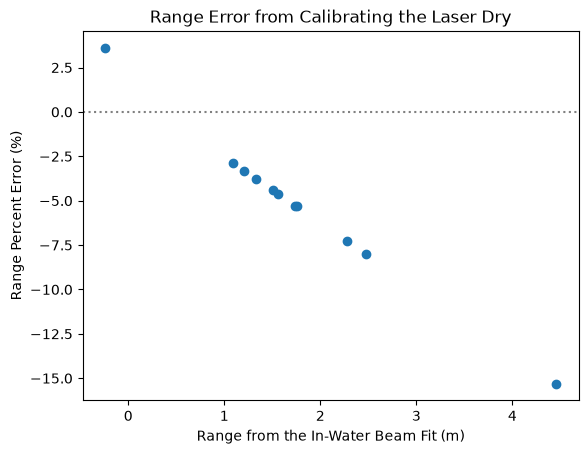

In [15]:
fig, ax = plt.subplots()

ax.plot(wet_ranges, percent, marker="o", linestyle="none")
ax.axhline(0.0, color="grey", linestyle=":")
ax.set_title("Range Error from Calibrating the Laser Dry")
ax.set_xlabel("Range from the In-Water Beam Fit (m)")
ax.set_ylabel("Range Percent Error (%)")

## Why range and length fail differently

Worth working through, because it decides which of these errors FishSense should
care about.

Suppose the camera model inflates all angles by a factor `s` — which is exactly
what an uncorrected flat port does, with `s` close to `n_water`. The laser fires
parallel to the optical axis with a metric offset `b`, so range comes from
`Z = b / tan(theta)` for a dot at angle `theta`:

- the model reports `theta_model = s * theta_true`, so `Z_est = Z_true / s`
- the transverse separation of two image points scales as `s` too
- length is `Z_est * s * |delta_u| = Z_true * |delta_u|` — **the scale cancels**

So a pure angular scale error corrupts the **range** by the full factor `s`, while
leaving **length** untouched. The two measurements do not fail together.

That is why `pool_validation.ipynb` found its metric length test uninformative,
and it is not an artifact of that notebook's design: for this laser geometry,
length really is self-correcting against pure scale errors. What survives in
length is only the *radial* part of the model error — the part the homography test
isolates.

The practical consequence for FishSense: an uncorrected flat port costs about
**25% in range** and much less in length. If range matters — habitat context,
volume sampled, anything georeferenced — the correction is not optional. If only
length matters, the stakes are the radial term.

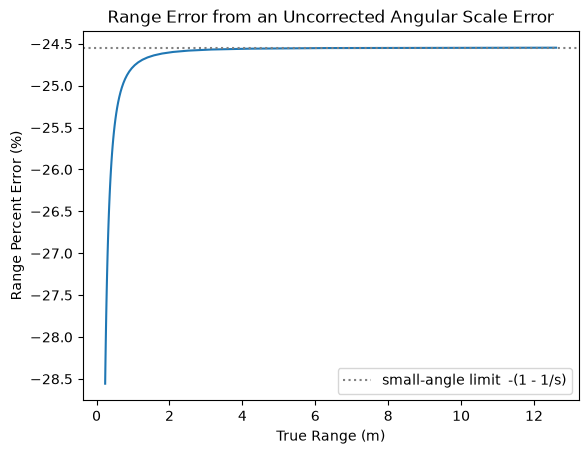

In [16]:
LENGTH_SCALE_DEMO = 1.3253   # the water/air focal ratio measured in pool_validation

theta = np.radians(np.linspace(0.5, 25.0, 50))
b = 0.11

true_range = b / np.tan(theta)
model_range = b / np.tan(LENGTH_SCALE_DEMO * theta)

fig, ax = plt.subplots()
ax.plot(true_range, (model_range - true_range) / true_range * 100)
ax.axhline(-(1 - 1 / LENGTH_SCALE_DEMO) * 100, color="grey", linestyle=":",
           label="small-angle limit  -(1 - 1/s)")
ax.set_title("Range Error from an Uncorrected Angular Scale Error")
ax.set_xlabel("True Range (m)")
ax.set_ylabel("Range Percent Error (%)")
ax.legend()

## Reading the result

All numbers are from **raw sensor coordinates**, with dots from
`LinearRawImage.bayer_excess`.

### Working in raw fixed the measurement

The in-air fit residual fell from **2.29 mm to 0.79 mm** — a factor of 2.9 —
purely by changing how the dot is located. The in-air frames were shot at f/2
against water's f/8 and their green channel is ~30% clipped at the dot, so a JPEG
centroid measures the middle of a clipped region rather than the middle of a
spot; on some frames it was wrong by 18 px. The Bayer green excess does not clip,
and it also recovered all 32 dots against 27 from the JPEGs.

Both fits are now tight: **0.79 mm in air, 0.42 mm in water**. That precision is
what makes the drift measurement below meaningful.

Robust fitting is load-bearing, not cosmetic. The raw pass picked up two
underwater frames whose dots are only a few pixels (244, 247); before rejection
they dragged the water fit to a 69 mm median residual with a 1.0 m worst case.

### The drift, measured

Two independent fits of the same beam, 48 minutes apart:

| | air (17:39) | water (18:27) |
|---|---|---|
| position at `z = 0` | (-33.6, -98.3) mm | (-31.1, -98.1) mm |
| tilt off optical axis | 0.48 deg | 0.27 deg |

**Direction differs by 0.378 deg; origin by 2.5 mm.** Substituting the air-fitted
beam into the underwater frames costs **-4.9% median range error** (-5.4% mean,
15.9% worst case).

### The disagreement is drift, not refraction

Two checks rule out the optical explanations.

*It is not fit noise.* The per-point direction error implied by the residuals is
0.0037 deg in air and 0.0024 deg in water. The measured 0.378 deg is roughly a
hundred times that.

*It is not refraction of a tilted beam.* A beam entering off-normal does bend, but
Snell shrinks the tilt **along its own direction** by about `n_water`: a
(0.457, -0.140) deg tilt in air should emerge as (0.343, -0.105) deg. The measured
water tilt is (0.095, -0.248) deg — the tilt *rotated* rather than shrank, and
sits 0.277 deg from the Snell prediction.

That is consistent with what is already known about this rig: the laser mount
moves. The beam is near enough to normal that refraction would barely touch it,
and the residual is mechanical.

### What this means for the measurement pipeline

**The number to carry forward is ~0.4 deg of drift, worth ~5% in range, over one
session boundary.** That is the error a stored laser calibration incurs, and it
sets how often the laser must be re-fitted — which for FishSense is every dive.

The division of labour this implies:

- **Camera**: calibrate once, in air. This is exactly what Pinax buys, and
  `pool_validation.ipynb` shows it costs nothing in geometry relative to an
  in-water calibration.
- **Laser**: self-calibrate per dive from the dive's own dots. No stored
  extrinsic survives a hand-carry at the precision the length measurement needs.

Notably these fail differently, which is lucky. For a beam parallel to the optical
axis, a camera scale error cancels in *length* (see the derivation below) and lands
entirely in *range*. Laser drift lands in range too. So length measurement — the
thing FishSense actually reports — is the more robust of the two quantities
against both error sources, while anything georeferenced is exposed to both.

### Caveats

- Nine underwater frames after rejection, nineteen in air: enough to compare two
  fits, not enough to be confident in either alone. The 0.378 deg is a single
  sample of drift, not a distribution.
- Both fits inherit `solvePnP` board-pose error, which is inside the residuals
  above and cannot be separated from dot-localisation error here.
- The wet fit applies Pinax with an assumed `n_water`; the pool was never measured.
- The pool laser session (092-109) holds 18 more dots at wider spread, on a fish
  decoy of unknown geometry. Recovering the pool-step geometry would roughly
  triple the in-water sample.
- One session boundary gives one drift sample. Characterising the drift
  *distribution* needs repeated fits across many dives — which the per-dive
  calibrations in the production pipeline already produce, and which would be a
  better source for it than this dataset.